<a href="https://colab.research.google.com/github/ShivtejLad/ShivtejLad/blob/main/ReservoirLoss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Libraries loaded.
✅ Database loaded: 14 reservoirs | 1994–2023 (30 yrs)

Processing reservoirs...

📊 STORAGE LOSS SUMMARY (sorted by severity):
  Reservoir   District  Original_Cap_Mm3  StorageLoss_pct  AnnualLoss_pct  Yr_50pct_loss
Khadakwasla       Pune              84.0             6.76           0.225           2215
      Ujani    Solapur            3340.0             5.00           0.167           2293
   Gangapur     Nashik             183.0             4.23           0.141           2348
       Mula Ahmednagar             543.0             3.77           0.126           2391
      Warna   Kolhapur             952.0             3.22           0.107           2459
     Warana   Kolhapur             161.0             2.96           0.099           2499
   Manikdoh       Pune             162.0             2.28           0.076           2649
     Mulshi       Pune             582.0             1.32           0.044           3126
Radhanagari   Kolhapur             380.0             

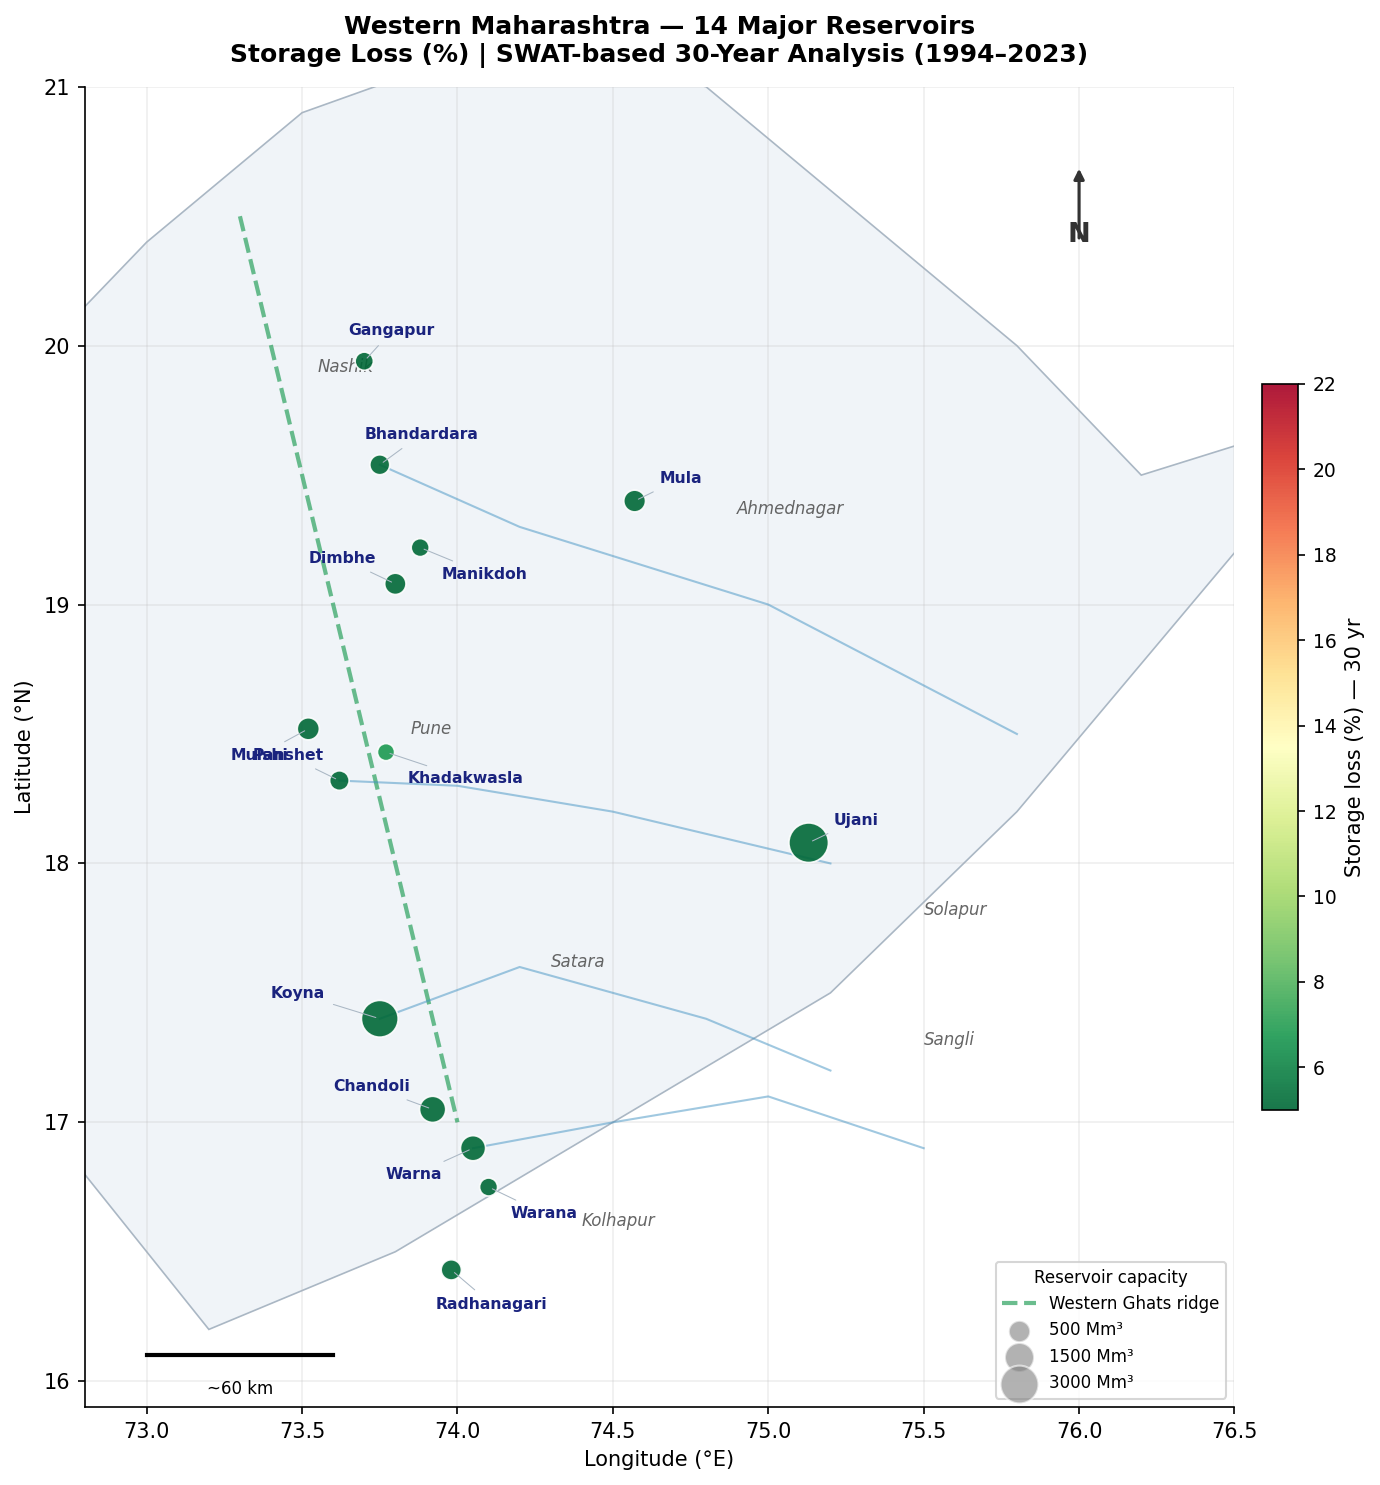

✅ Static map saved → outputs/static_reservoir_map.png


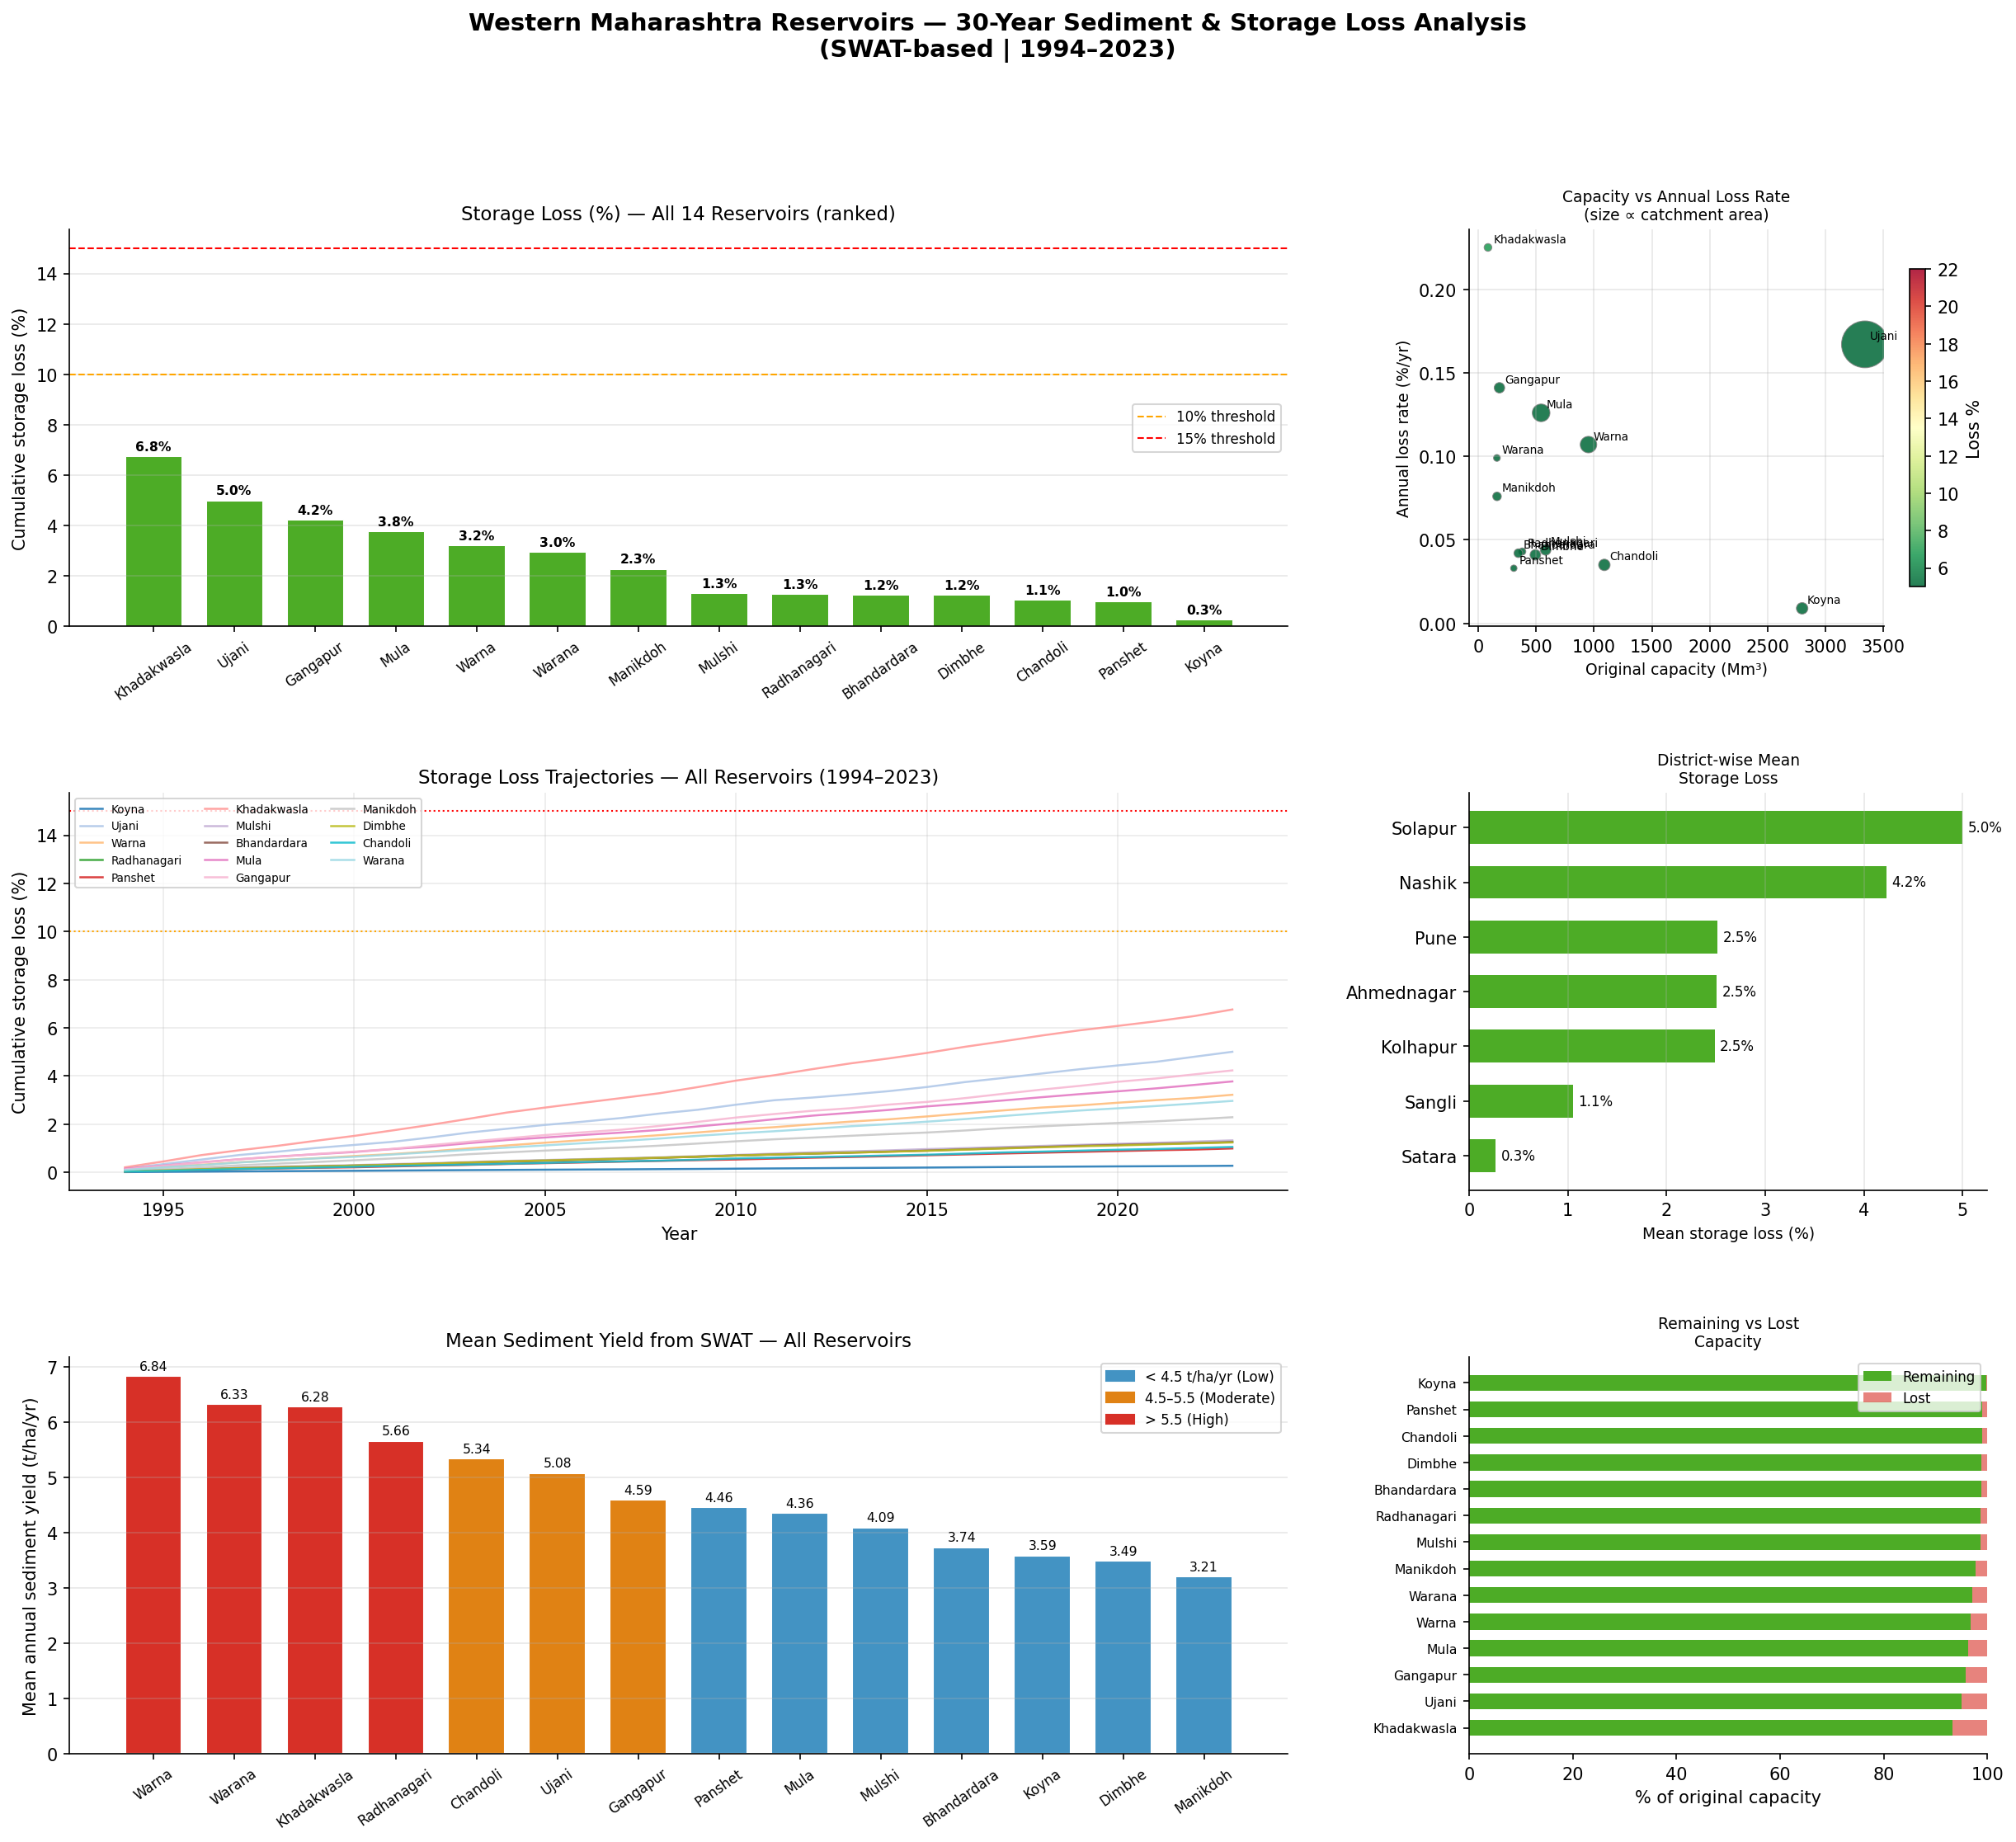

✅ Multi-reservoir figure saved → outputs/multi_reservoir_analysis.png


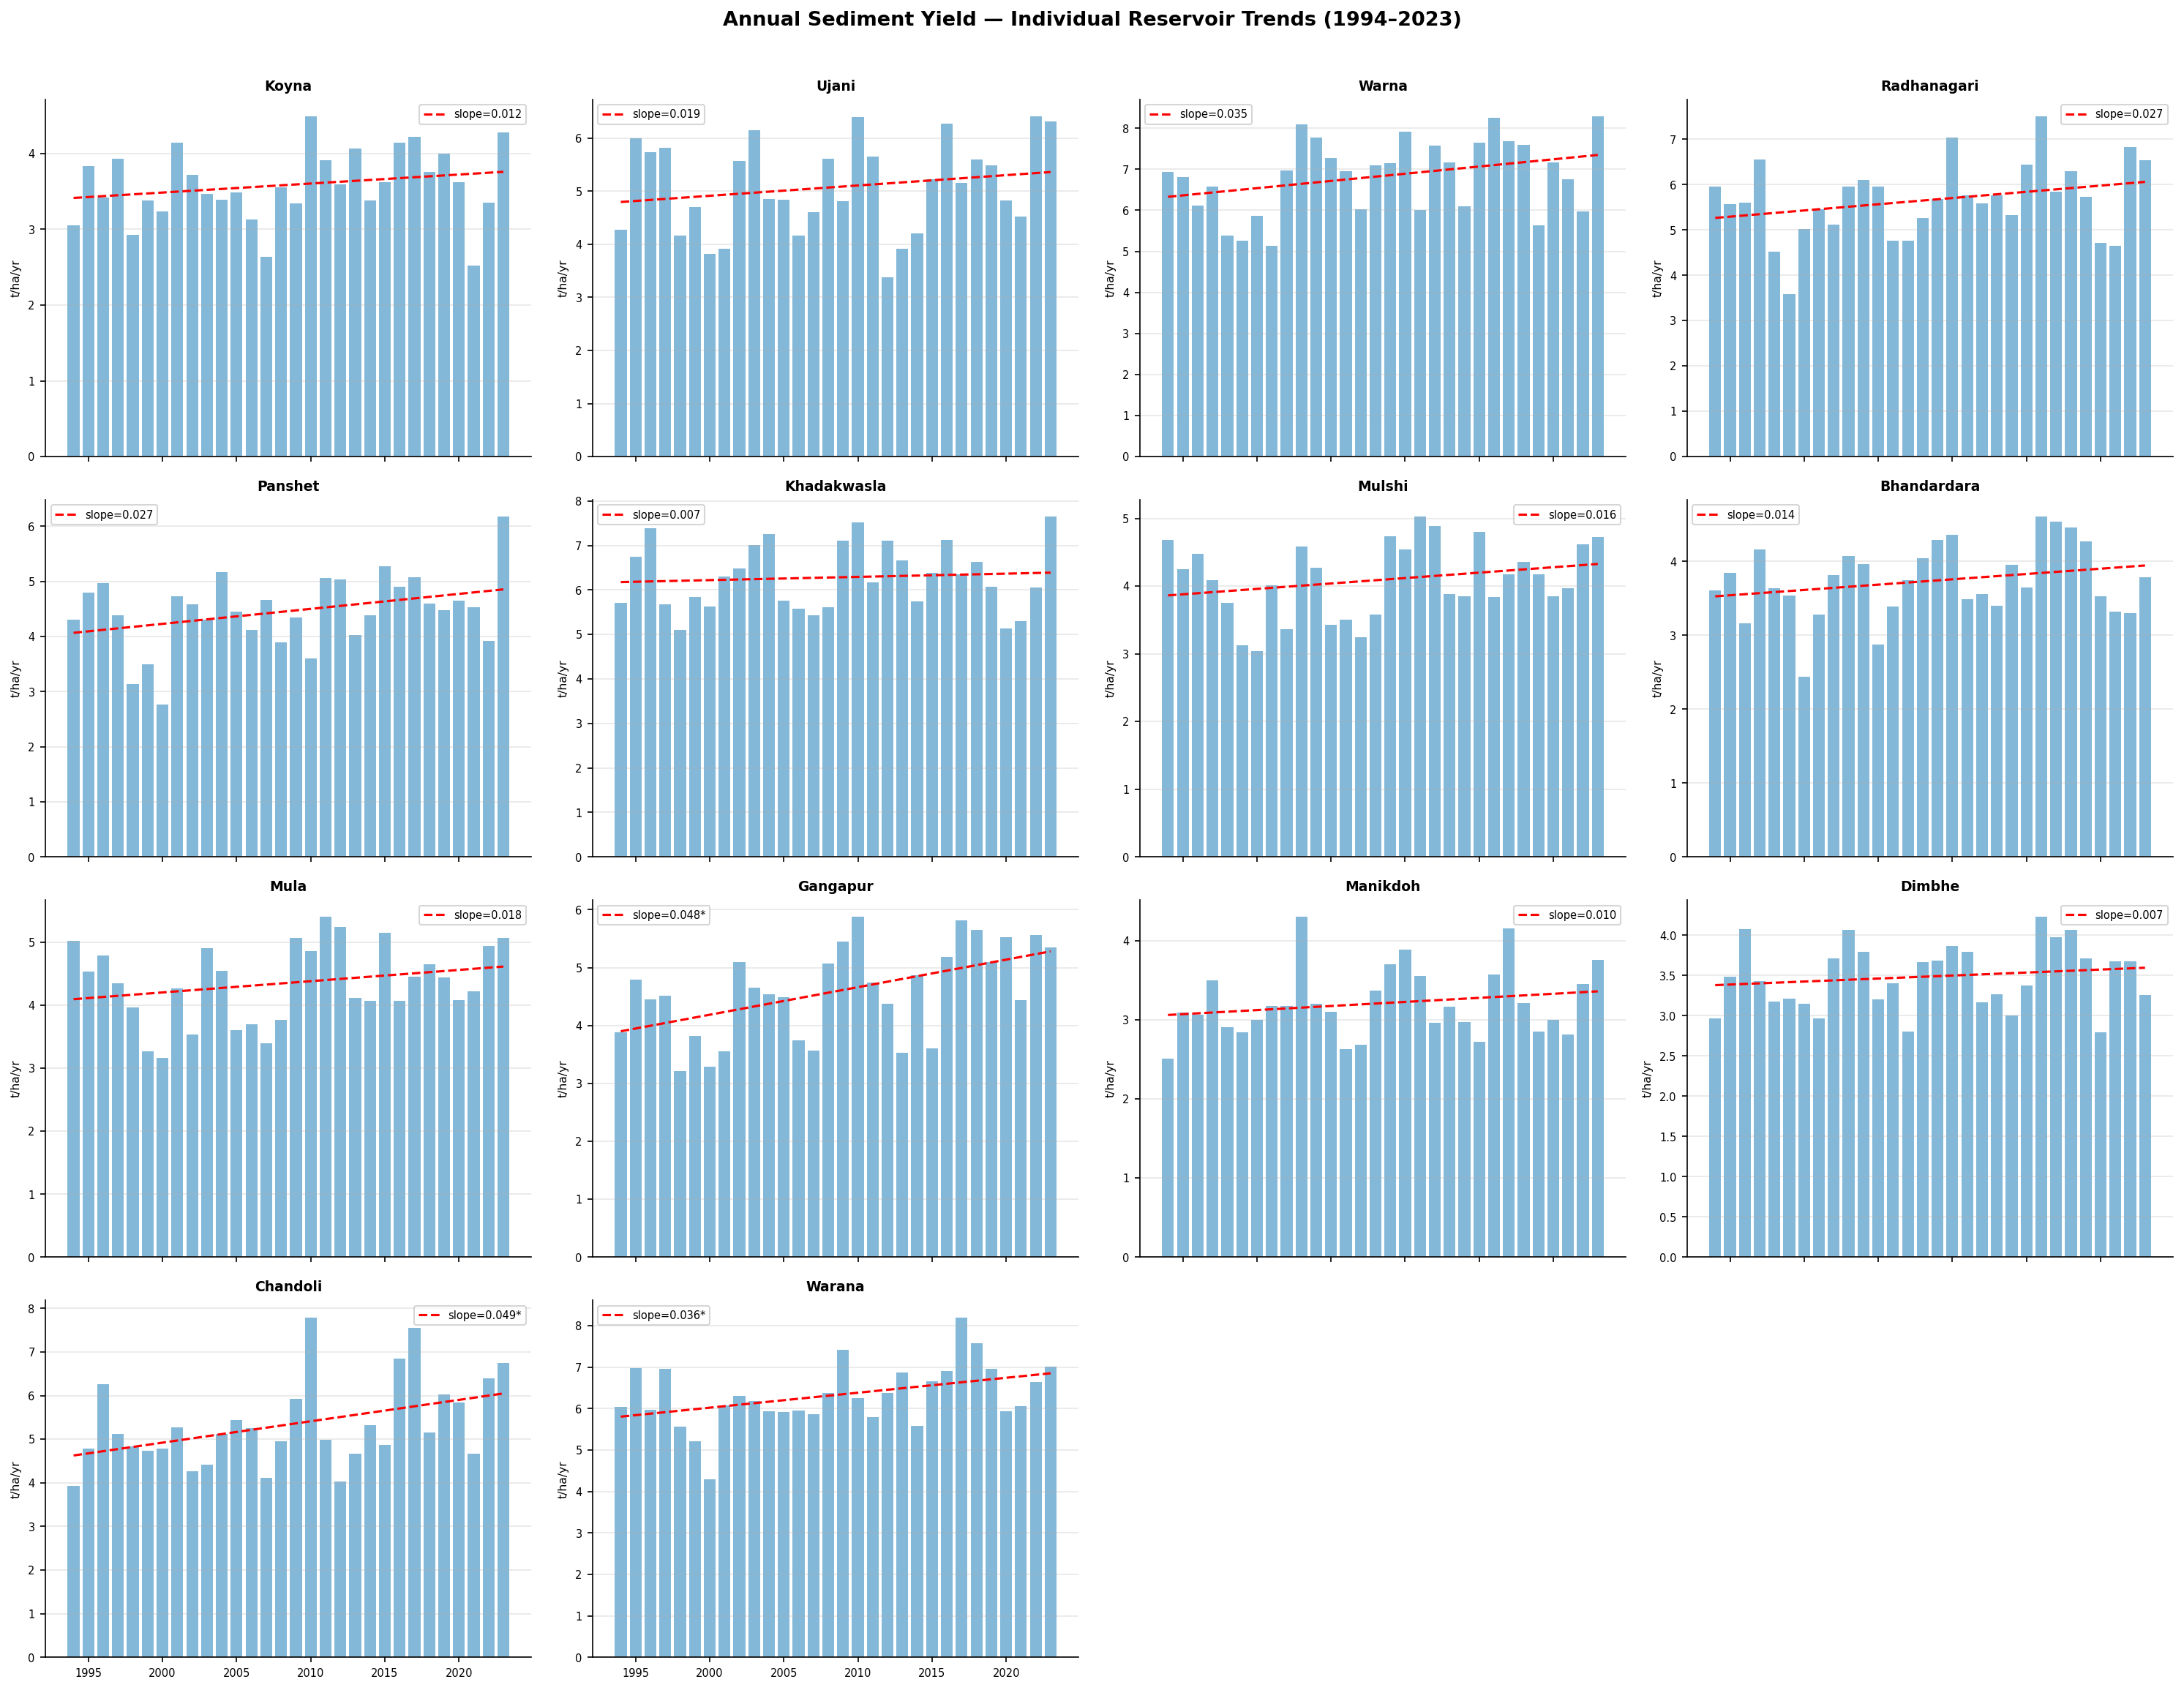

✅ Individual time-series saved → outputs/individual_sediment_timeseries.png

✅ Excel results saved → outputs/western_maharashtra_sediment_results.xlsx

  WESTERN MAHARASHTRA RESERVOIR SEDIMENTATION REPORT
  Period: 1994–2023  |  14 reservoirs
  Total original storage   : 11,419.4 Mm³
  Total remaining storage  : 11,134.3 Mm³
  Total storage lost       : 285.1 Mm³  (2.5%)
  Regional mean loss       : 2.5%
  Worst affected           : Khadakwasla (6.76%)
  Least affected           : Koyna (0.27%)
  High-risk (>15% loss)    : 0 reservoirs
  Moderate (10–15% loss)   : 0 reservoirs
  Low risk (<10% loss)     : 14 reservoirs

✅ Analysis complete. Outputs in: /content/outputs
   📂 reservoir_map.html        → Open in browser (interactive)
   📂 static_reservoir_map.png  → Publication-quality map
   📂 multi_reservoir_analysis.png
   📂 individual_sediment_timeseries.png
   📂 western_maharashtra_sediment_results.xlsx


In [5]:
# =============================================================================
# WESTERN MAHARASHTRA — MULTI-RESERVOIR SEDIMENT & STORAGE LOSS ANALYSIS
# 14 Major Dams | 30-Year Analysis (1994–2023)
# Includes: Interactive Map (Folium) + Matplotlib Figures + Excel Export
# Author : [Your Name] | CWGS, TNAU
# Workflow: SWAT Sediment Output → Storage Loss → Interactive Map
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 0 — INSTALL & IMPORTS (run first in Google Colab)
# ─────────────────────────────────────────────────────────────────────────────

# !pip install pandas numpy matplotlib seaborn scipy openpyxl folium pymannkendall branca

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
import warnings, os, json

try:
    import folium
    from folium import plugins
    from branca.colormap import LinearColormap
    FOLIUM_AVAILABLE = True
except ImportError:
    FOLIUM_AVAILABLE = False
    print("⚠️  folium not installed — run: !pip install folium branca")

try:
    import pymannkendall as mk
    MK_AVAILABLE = True
except ImportError:
    MK_AVAILABLE = False

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 150, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
})

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Libraries loaded.")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — WESTERN MAHARASHTRA RESERVOIR DATABASE
# 14 Major Dams: Koyna, Ujani, Warna, Radhanagari, Panshet, Khadakwasla,
#                Mulshi, Bhandardara, Mula, Gangapur, Manikdoh, Dimbhe,
#                Chandoli, Warana
# ─────────────────────────────────────────────────────────────────────────────

RESERVOIR_DB = [
    # name, river, district, lat, lon, cap_mm3, catchment_km2, bulk_density, trap_eff%, year_built, type
    dict(name="Koyna",           river="Koyna",     district="Satara",     lat=17.40, lon=73.75, cap=2797.4, area=891.8,  bd=1.20, te=94, year=1964, rtype="Hydro + Storage"),
    dict(name="Ujani",           river="Bhima",     district="Solapur",    lat=18.08, lon=75.13, cap=3340.0, area=14856,  bd=1.30, te=96, year=1980, rtype="Multipurpose"),
    dict(name="Warna",           river="Warna",     district="Kolhapur",   lat=16.90, lon=74.05, cap=952.0,  area=1846,   bd=1.15, te=93, year=1985, rtype="Irrigation"),
    dict(name="Radhanagari",     river="Bhogawati", district="Kolhapur",   lat=16.43, lon=73.98, cap=380.0,  area=345,    bd=1.10, te=91, year=1955, rtype="Irrigation"),
    dict(name="Panshet",         river="Ambi",      district="Pune",       lat=18.32, lon=73.62, cap=307.0,  area=282,    bd=1.12, te=90, year=1961, rtype="Water Supply"),
    dict(name="Khadakwasla",     river="Mutha",     district="Pune",       lat=18.43, lon=73.77, cap=84.0,   area=404,    bd=1.18, te=88, year=1879, rtype="Multipurpose"),
    dict(name="Mulshi",          river="Mula",      district="Pune",       lat=18.52, lon=73.52, cap=582.0,  area=769,    bd=1.14, te=93, year=1927, rtype="Hydro"),
    dict(name="Bhandardara",     river="Pravara",   district="Ahmednagar", lat=19.54, lon=73.75, cap=346.0,  area=512,    bd=1.22, te=92, year=1926, rtype="Irrigation"),
    dict(name="Mula",            river="Mula",      district="Ahmednagar", lat=19.40, lon=74.57, cap=543.0,  area=2107,   bd=1.25, te=93, year=1972, rtype="Irrigation"),
    dict(name="Gangapur",        river="Godavari",  district="Nashik",     lat=19.94, lon=73.70, cap=183.0,  area=741,    bd=1.20, te=91, year=1954, rtype="Water Supply"),
    dict(name="Manikdoh",        river="Kukadi",    district="Pune",       lat=19.22, lon=73.88, cap=162.0,  area=504,    bd=1.18, te=90, year=1980, rtype="Irrigation"),
    dict(name="Dimbhe",          river="Ghod",      district="Pune",       lat=19.08, lon=73.80, cap=493.0,  area=760,    bd=1.20, te=92, year=1981, rtype="Multipurpose"),
    dict(name="Chandoli",        river="Warna",     district="Sangli",     lat=17.05, lon=73.92, cap=1089.0, area=892,    bd=1.16, te=93, year=1994, rtype="Storage"),
    dict(name="Warana",          river="Warna",     district="Kolhapur",   lat=16.75, lon=74.10, cap=161.0,  area=312,    bd=1.13, te=91, year=1968, rtype="Irrigation"),
]

START_YEAR = 1994
END_YEAR   = 2023
YEARS      = np.arange(START_YEAR, END_YEAR + 1)
N_YEARS    = len(YEARS)

print(f"✅ Database loaded: {len(RESERVOIR_DB)} reservoirs | {START_YEAR}–{END_YEAR} ({N_YEARS} yrs)")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2 — SWAT OUTPUT LOADER
# Place your SWAT CSV files named as: "<ReservoirName>_swat.csv"
# Required columns: Year, SedYield_t_ha
# Optional columns: Precip_mm, Runoff_mm
# ─────────────────────────────────────────────────────────────────────────────

# Realistic sediment yield profiles for western Maharashtra
# Based on RUSLE/SWAT literature for Western Ghats (t/ha/yr)
_BASE_YIELDS = {
    "Koyna":       (3.2, 0.8, 0.020),   # (mean, std, trend)
    "Ujani":       (4.5, 1.1, 0.040),
    "Warna":       (5.8, 1.4, 0.055),
    "Radhanagari": (5.1, 1.3, 0.050),
    "Panshet":     (3.9, 0.9, 0.030),
    "Khadakwasla": (5.4, 1.3, 0.052),
    "Mulshi":      (3.6, 0.8, 0.025),
    "Bhandardara": (3.4, 0.7, 0.022),
    "Mula":        (3.8, 0.9, 0.028),
    "Gangapur":    (4.1, 1.0, 0.035),
    "Manikdoh":    (2.9, 0.6, 0.018),
    "Dimbhe":      (3.1, 0.7, 0.020),
    "Chandoli":    (4.7, 1.2, 0.038),
    "Warana":      (5.5, 1.3, 0.053),
}

def load_or_generate_swat(reservoir: dict, swat_dir: str = ".") -> pd.DataFrame:
    """Load SWAT CSV if present, else generate realistic synthetic data."""
    name = reservoir["name"]
    fpath = os.path.join(swat_dir, f"{name}_swat.csv")
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df.columns = df.columns.str.strip()
        df = df[(df["Year"] >= START_YEAR) & (df["Year"] <= END_YEAR)].reset_index(drop=True)
        print(f"  ✅ {name}: loaded from {fpath}")
        return df
    # Synthetic generation
    np.random.seed(hash(name) % 999)
    mu, sigma, trend_rate = _BASE_YIELDS.get(name, (4.0, 1.0, 0.030))
    t = YEARS - START_YEAR
    base  = mu + trend_rate * t
    cycle = 0.6 * sigma * np.sin(2 * np.pi * t / 7)
    noise = np.random.normal(0, sigma * 0.5, N_YEARS)
    sed   = np.clip(base + cycle + noise, 0.4, 15.0)
    runoff = 250 + 80 * np.sin(np.pi * t / 14) + np.random.normal(0, 30, N_YEARS)
    precip = 850 + 220 * np.sin(np.pi * t / 12) + np.random.normal(0, 70, N_YEARS)
    return pd.DataFrame({"Year": YEARS, "SedYield_t_ha": np.round(sed,3),
                         "Runoff_mm": np.round(runoff,1), "Precip_mm": np.round(precip,1)})

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3 — COMPUTE STORAGE LOSS FOR ALL RESERVOIRS
# ─────────────────────────────────────────────────────────────────────────────

def compute_storage_loss(df_swat: pd.DataFrame, res: dict) -> pd.DataFrame:
    """Convert annual sediment yield → volume → cumulative storage loss."""
    A_ha   = res["area"] * 100
    TE     = res["te"] / 100
    BD     = res["bd"]
    C0_m3  = res["cap"] * 1e6

    df = df_swat.copy()
    df["Sed_Inflow_t"]    = df["SedYield_t_ha"] * A_ha
    df["Sed_Trapped_t"]   = df["Sed_Inflow_t"] * TE
    df["Sed_Volume_m3"]   = df["Sed_Trapped_t"] / BD
    df["CumVol_m3"]       = df["Sed_Volume_m3"].cumsum()
    df["Capacity_Mm3"]    = (C0_m3 - df["CumVol_m3"]) / 1e6
    df["StorageLoss_pct"] = df["CumVol_m3"] / C0_m3 * 100
    if "Runoff_mm" in df.columns:
        df["Inflow_m3"]   = (df["Runoff_mm"] / 1000) * (res["area"] * 1e6)
        df["CI_ratio"]    = (C0_m3 - df["CumVol_m3"]) / df["Inflow_m3"].clip(lower=1)
    return df

# Run for all reservoirs
ALL_DATA = {}
SUMMARY  = []

print("\nProcessing reservoirs...")
for res in RESERVOIR_DB:
    df_swat = load_or_generate_swat(res)
    df_out  = compute_storage_loss(df_swat, res)
    ALL_DATA[res["name"]] = df_out

    # Trend
    slope, intercept, r, p, _ = stats.linregress(df_out["Year"], df_out["SedYield_t_ha"])
    total_loss_pct = df_out["StorageLoss_pct"].iloc[-1]
    ann_rate = total_loss_pct / N_YEARS
    yr50 = round(END_YEAR + (50 - total_loss_pct) / ann_rate) if total_loss_pct < 50 else "< 2023"

    SUMMARY.append({
        "Reservoir"          : res["name"],
        "River"              : res["river"],
        "District"           : res["district"],
        "Year_Built"         : res["year"],
        "Original_Cap_Mm3"   : res["cap"],
        "Remaining_Cap_Mm3"  : round(df_out["Capacity_Mm3"].iloc[-1], 2),
        "TotalLoss_Mm3"      : round((df_out["CumVol_m3"].iloc[-1]) / 1e6, 3),
        "StorageLoss_pct"    : round(total_loss_pct, 2),
        "AnnualLoss_pct"     : round(ann_rate, 3),
        "Mean_SedYield_t_ha" : round(df_out["SedYield_t_ha"].mean(), 3),
        "Trend_slope"        : round(slope, 4),
        "Trend_p"            : round(p, 4),
        "Trend_sig"          : "Yes" if p < 0.05 else "No",
        "Yr_50pct_loss"      : yr50,
        "Lat"                : res["lat"],
        "Lon"                : res["lon"],
        "Catchment_km2"      : res["area"],
        "Type"               : res["rtype"],
    })

summary_df = pd.DataFrame(SUMMARY).sort_values("StorageLoss_pct", ascending=False).reset_index(drop=True)
print("\n📊 STORAGE LOSS SUMMARY (sorted by severity):")
print(summary_df[["Reservoir","District","Original_Cap_Mm3","StorageLoss_pct","AnnualLoss_pct","Yr_50pct_loss"]].to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4 — INTERACTIVE MAP (FOLIUM)
# Generates: reservoir_map.html — open in any browser
# ─────────────────────────────────────────────────────────────────────────────

def build_interactive_map(summary_df: pd.DataFrame, output_path: str) -> None:
    """Build a Folium choropleth-style map with popup cards for each reservoir."""
    if not FOLIUM_AVAILABLE:
        print("⚠️  Folium not available — skipping map.")
        return

    m = folium.Map(
        location=[18.2, 74.2],
        zoom_start=7,
        tiles="CartoDB positron",
        attr="© CartoDB © OSM"
    )

    # Color scale for storage loss
    colormap = LinearColormap(
        colors=["#4dac26", "#fee090", "#d73027"],
        vmin=summary_df["StorageLoss_pct"].min(),
        vmax=summary_df["StorageLoss_pct"].max(),
        caption="Storage Loss (%) — 30-year cumulative"
    )
    colormap.add_to(m)

    # Add reservoir markers
    for _, row in summary_df.iterrows():
        color  = colormap(row["StorageLoss_pct"])
        radius = max(6, min(16, row["Original_Cap_Mm3"] / 250))

        # Popup HTML card
        popup_html = f"""
        <div style="font-family:Arial,sans-serif;width:240px;font-size:12px">
          <div style="background:#2166ac;color:white;padding:6px 10px;border-radius:4px 4px 0 0;font-weight:bold;font-size:13px">
            {row['Reservoir']} Reservoir
          </div>
          <div style="background:#f7f7f7;padding:8px 10px;border:1px solid #ddd;border-top:none;border-radius:0 0 4px 4px">
            <table style="width:100%;border-collapse:collapse">
              <tr><td style="color:#666;padding:2px 0">River</td><td style="text-align:right;font-weight:bold">{row['River']}</td></tr>
              <tr><td style="color:#666;padding:2px 0">District</td><td style="text-align:right;font-weight:bold">{row['District']}</td></tr>
              <tr><td style="color:#666;padding:2px 0">Built</td><td style="text-align:right;font-weight:bold">{row['Year_Built']}</td></tr>
              <tr><td style="color:#666;padding:2px 0">Type</td><td style="text-align:right;font-weight:bold">{row['Type']}</td></tr>
              <tr><td style="color:#666;padding:2px 0">Catchment</td><td style="text-align:right;font-weight:bold">{row['Catchment_km2']:,} km²</td></tr>
              <tr style="background:#fff3cd"><td style="color:#333;padding:3px 0"><b>Original capacity</b></td><td style="text-align:right;font-weight:bold">{row['Original_Cap_Mm3']} Mm³</td></tr>
              <tr style="background:#fff3cd"><td style="color:#333;padding:3px 0"><b>Remaining capacity</b></td><td style="text-align:right;font-weight:bold">{row['Remaining_Cap_Mm3']} Mm³</td></tr>
              <tr style="background:#{'ffd7d7' if row['StorageLoss_pct']>15 else 'fff3cd' if row['StorageLoss_pct']>10 else 'e6f4ea'}">
                <td style="color:#333;padding:3px 0"><b>Storage loss</b></td>
                <td style="text-align:right;font-weight:bold;color:{'#a32d2d' if row['StorageLoss_pct']>15 else '#854f0b' if row['StorageLoss_pct']>10 else '#3b6d11'}">{row['StorageLoss_pct']}%</td>
              </tr>
              <tr><td style="color:#666;padding:2px 0">Annual loss rate</td><td style="text-align:right;font-weight:bold">{row['AnnualLoss_pct']}% / yr</td></tr>
              <tr><td style="color:#666;padding:2px 0">Mean sed. yield</td><td style="text-align:right;font-weight:bold">{row['Mean_SedYield_t_ha']} t/ha/yr</td></tr>
              <tr style="background:#e8eaf6"><td style="color:#333;padding:3px 0"><b>Est. 50% loss by</b></td><td style="text-align:right;font-weight:bold;color:#1a237e">{row['Yr_50pct_loss']}</td></tr>
            </table>
          </div>
        </div>
        """

        folium.CircleMarker(
            location=[row["Lat"], row["Lon"]],
            radius=radius,
            color="white",
            weight=1.5,
            fill=True,
            fill_color=color,
            fill_opacity=0.88,
            tooltip=folium.Tooltip(
                f"<b>{row['Reservoir']}</b><br>Loss: {row['StorageLoss_pct']}% | {row['Original_Cap_Mm3']} Mm³",
                permanent=False
            ),
            popup=folium.Popup(folium.Html(popup_html, script=True), max_width=260),
        ).add_to(m)

        # Dam label
        folium.Marker(
            location=[row["Lat"] + 0.06, row["Lon"]],
            icon=folium.DivIcon(
                html=f'<div style="font-size:9px;color:#1a237e;font-weight:bold;white-space:nowrap">{row["Reservoir"]}</div>',
                icon_size=(80, 12), icon_anchor=(0, 0)
            )
        ).add_to(m)

    # Add Western Ghats label
    folium.Marker(
        location=[17.5, 73.6],
        icon=folium.DivIcon(
            html='<div style="font-size:10px;color:#0F6E56;font-style:italic;font-weight:bold;transform:rotate(-70deg)">Western Ghats</div>',
            icon_size=(120, 16), icon_anchor=(60, 8)
        )
    ).add_to(m)

    # Legend panel
    legend_html = """
    <div style="position:fixed;bottom:30px;left:30px;background:white;border:1px solid #ccc;
                border-radius:8px;padding:12px 16px;font-family:Arial;font-size:11px;z-index:9999;
                box-shadow:2px 2px 6px rgba(0,0,0,0.2);min-width:180px">
      <b style="font-size:12px">Western Maharashtra</b><br>
      <b style="font-size:12px">Major Reservoirs</b>
      <hr style="margin:6px 0">
      <div style="margin:3px 0"><span style="display:inline-block;width:12px;height:12px;background:#4dac26;border-radius:50%;vertical-align:middle;margin-right:6px"></span>&lt; 10% loss (Low)</div>
      <div style="margin:3px 0"><span style="display:inline-block;width:12px;height:12px;background:#fee090;border-radius:50%;vertical-align:middle;margin-right:6px"></span>10–15% loss (Moderate)</div>
      <div style="margin:3px 0"><span style="display:inline-block;width:12px;height:12px;background:#d73027;border-radius:50%;vertical-align:middle;margin-right:6px"></span>&gt; 15% loss (High)</div>
      <hr style="margin:6px 0">
      <div style="color:#666">Marker size ∝ capacity</div>
      <div style="color:#666">Click marker for details</div>
      <div style="color:#666;margin-top:4px">Period: 1994–2023 (30 yr)</div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))

    # Title
    title_html = """
    <div style="position:fixed;top:10px;left:50%;transform:translateX(-50%);
                background:white;border:1px solid #ccc;border-radius:8px;
                padding:8px 20px;font-family:Arial;font-size:14px;font-weight:bold;
                color:#1a237e;z-index:9999;box-shadow:2px 2px 6px rgba(0,0,0,0.2);
                text-align:center">
      Western Maharashtra Reservoirs — 30-Year Sediment & Storage Loss Assessment<br>
      <span style="font-size:11px;font-weight:normal;color:#555">SWAT-based analysis | 1994–2023 | Click any marker for full details</span>
    </div>
    """
    m.get_root().html.add_child(folium.Element(title_html))

    m.save(output_path)
    print(f"\n🗺️  Interactive map saved → {output_path}")
    print("   Open this HTML file in your browser for the full interactive experience.")


map_path = os.path.join(OUTPUT_DIR, "western_maharashtra_reservoir_map.html")
build_interactive_map(summary_df, map_path)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — STATIC MAP FIGURE (Matplotlib)
# For publications / thesis figures
# ─────────────────────────────────────────────────────────────────────────────

def plot_static_map(summary_df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(10, 10))

    # Approximate Maharashtra boundary (simplified polygon)
    mh_lon = [72.6,73.0,73.5,74.2,74.8,75.2,75.8,76.2,77.0,77.8,78.5,79.0,
               79.2,78.8,78.0,77.5,77.0,76.5,75.8,75.2,74.5,73.8,73.2,72.8,72.6]
    mh_lat = [19.9,20.4,20.9,21.2,21.0,20.6,20.0,19.5,19.8,20.2,20.5,20.8,
               21.1,21.4,21.2,20.8,20.0,19.2,18.2,17.5,17.0,16.5,16.2,16.8,19.9]
    ax.fill(mh_lon, mh_lat, fc="#f0f4f8", ec="#aab7c4", lw=0.8, zorder=1)

    # Western Ghats ridge
    ax.plot([73.3,73.4,73.5,73.6,73.7,73.8,73.9,74.0],
            [20.5,20.0,19.5,19.0,18.5,18.0,17.5,17.0],
            color="#2ca25f", lw=2, ls="--", alpha=0.7, zorder=2, label="Western Ghats ridge")

    # Rivers (simplified)
    rivers = [
        ([73.75,74.2,74.8,75.2], [17.40,17.6,17.4,17.2], "Koyna/Krishna"),
        ([74.05,74.5,75.0,75.5], [16.90,17.0,17.1,16.9], "Warna"),
        ([73.75,74.2,75.0,75.8], [19.54,19.3,19.0,18.5], "Pravara/Godavari"),
        ([73.62,74.0,74.5,75.2], [18.32,18.3,18.2,18.0], "Mutha/Bhima"),
    ]
    for lons, lats, rname in rivers:
        ax.plot(lons, lats, color="#4393c3", lw=1.0, alpha=0.5, zorder=2)

    # Color by storage loss
    norm    = mcolors.Normalize(vmin=5, vmax=22)
    cmap    = plt.cm.RdYlGn_r
    sizes   = (summary_df["Original_Cap_Mm3"] / summary_df["Original_Cap_Mm3"].max() * 300 + 60).values

    sc = ax.scatter(
        summary_df["Lon"], summary_df["Lat"],
        c=summary_df["StorageLoss_pct"],
        s=sizes, cmap=cmap, norm=norm,
        edgecolors="white", linewidths=0.8, zorder=5, alpha=0.9
    )

    # Labels
    offsets = {
        "Koyna":(-0.35,0.08),"Ujani":(0.08,0.07),"Warna":(-0.28,-0.12),
        "Radhanagari":(-0.05,-0.15),"Panshet":(-0.28,0.08),"Khadakwasla":(0.07,-0.12),
        "Mulshi":(-0.25,-0.12),"Bhandardara":(-0.05,0.1),"Mula":(0.08,0.07),
        "Gangapur":(-0.05,0.1),"Manikdoh":(0.07,-0.12),"Dimbhe":(-0.28,0.08),
        "Chandoli":(-0.32,0.07),"Warana":(0.07,-0.12),
    }
    for _, row in summary_df.iterrows():
        dx, dy = offsets.get(row["Reservoir"], (0.06, 0.06))
        ax.annotate(
            row["Reservoir"],
            (row["Lon"], row["Lat"]),
            xytext=(row["Lon"] + dx, row["Lat"] + dy),
            fontsize=7.5, color="#1a237e", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#aab7c4", lw=0.5),
            zorder=6
        )

    # Colorbar
    cb = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.02, label="Storage loss (%) — 30 yr")
    cb.ax.tick_params(labelsize=9)

    # Size legend
    for cap, lbl in [(500,"500 Mm³"),(1500,"1500 Mm³"),(3000,"3000 Mm³")]:
        s = cap / summary_df["Original_Cap_Mm3"].max() * 300 + 60
        ax.scatter([], [], s=s, c="gray", alpha=0.6, label=lbl, edgecolors="white")

    # District labels
    districts = [
        (18.5,73.85,"Pune"),(19.9,73.55,"Nashik"),(19.35,74.9,"Ahmednagar"),
        (17.6,74.3,"Satara"),(16.6,74.4,"Kolhapur"),(17.3,75.5,"Sangli"),
        (17.8,75.5,"Solapur"),
    ]
    for lat, lon, name in districts:
        ax.text(lon, lat, name, fontsize=8, color="#555", fontstyle="italic", alpha=0.9)

    ax.set_xlim(72.8, 76.5); ax.set_ylim(15.9, 21.0)
    ax.set_xlabel("Longitude (°E)", fontsize=10)
    ax.set_ylabel("Latitude (°N)", fontsize=10)
    ax.set_title("Western Maharashtra — 14 Major Reservoirs\nStorage Loss (%) | SWAT-based 30-Year Analysis (1994–2023)",
                 fontsize=12, fontweight="bold", pad=12)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.8, title="Reservoir capacity", title_fontsize=8)
    ax.grid(alpha=0.2)

    # North arrow
    ax.annotate("N", xy=(76.0, 20.4), fontsize=13, fontweight="bold", ha="center", color="#333")
    ax.annotate("", xy=(76.0, 20.7), xytext=(76.0, 20.4),
                arrowprops=dict(arrowstyle="-|>", color="#333", lw=1.5))
    # Scale bar (approx)
    ax.plot([73.0, 73.6], [16.1, 16.1], "k-", lw=2)
    ax.text(73.3, 15.95, "~60 km", ha="center", fontsize=8)

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "static_reservoir_map.png")
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"✅ Static map saved → {path}")

plot_static_map(summary_df)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6 — MULTI-RESERVOIR COMPARATIVE FIGURES
# ─────────────────────────────────────────────────────────────────────────────

def plot_comparative(summary_df: pd.DataFrame, all_data: dict) -> None:
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle("Western Maharashtra Reservoirs — 30-Year Sediment & Storage Loss Analysis\n(SWAT-based | 1994–2023)",
                 fontsize=14, fontweight="bold", y=0.99)
    gs = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

    cmap14 = plt.cm.tab20(np.linspace(0, 1, 14))

    # ── 6.1 Storage loss bar chart ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :2])
    colors_bar = ["#d73027" if v > 15 else "#fee090" if v > 10 else "#4dac26"
                  for v in summary_df["StorageLoss_pct"]]
    bars = ax1.bar(summary_df["Reservoir"], summary_df["StorageLoss_pct"],
                   color=colors_bar, width=0.7, edgecolor="white", linewidth=0.5)
    ax1.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=7.5, fontweight="bold")
    ax1.axhline(10, color="orange", ls="--", lw=1, label="10% threshold")
    ax1.axhline(15, color="red",    ls="--", lw=1, label="15% threshold")
    ax1.set_ylabel("Cumulative storage loss (%)")
    ax1.set_title("Storage Loss (%) — All 14 Reservoirs (ranked)", fontsize=11)
    ax1.tick_params(axis="x", rotation=35, labelsize=8)
    ax1.legend(fontsize=8); ax1.grid(axis="y", alpha=0.3)

    # ── 6.2 Annual loss rate scatter ─────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 2])
    sc = ax2.scatter(summary_df["Original_Cap_Mm3"], summary_df["AnnualLoss_pct"],
                     s=summary_df["Catchment_km2"]/20, c=summary_df["StorageLoss_pct"],
                     cmap="RdYlGn_r", vmin=5, vmax=22, edgecolors="gray", linewidths=0.5, alpha=0.85)
    for _, r in summary_df.iterrows():
        ax2.annotate(r["Reservoir"], (r["Original_Cap_Mm3"], r["AnnualLoss_pct"]),
                     fontsize=6.5, xytext=(3, 3), textcoords="offset points")
    plt.colorbar(sc, ax=ax2, label="Loss %", shrink=0.8)
    ax2.set_xlabel("Original capacity (Mm³)", fontsize=9)
    ax2.set_ylabel("Annual loss rate (%/yr)", fontsize=9)
    ax2.set_title("Capacity vs Annual Loss Rate\n(size ∝ catchment area)", fontsize=9)
    ax2.grid(alpha=0.3)

    # ── 6.3 Cumulative storage loss time-series (all reservoirs) ─────────────
    ax3 = fig.add_subplot(gs[1, :2])
    for i, (name, df_r) in enumerate(all_data.items()):
        loss = summary_df.loc[summary_df["Reservoir"] == name, "StorageLoss_pct"].values[0]
        lw   = 2.0 if loss > 15 else 1.2
        ax3.plot(df_r["Year"], df_r["StorageLoss_pct"], color=cmap14[i], lw=lw,
                 label=name, alpha=0.88)
    ax3.axhline(10, color="orange", ls=":", lw=1); ax3.axhline(15, color="red", ls=":", lw=1)
    ax3.set_xlabel("Year"); ax3.set_ylabel("Cumulative storage loss (%)")
    ax3.set_title("Storage Loss Trajectories — All Reservoirs (1994–2023)", fontsize=11)
    ax3.legend(fontsize=6.5, ncol=3, loc="upper left"); ax3.grid(alpha=0.25)

    # ── 6.4 District-wise aggregated loss ────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 2])
    dist_grp = summary_df.groupby("District").agg(
        Mean_Loss=("StorageLoss_pct","mean"),
        N=("StorageLoss_pct","count"),
        Total_Cap=("Original_Cap_Mm3","sum")
    ).sort_values("Mean_Loss", ascending=True)
    cols_d = ["#d73027" if v > 15 else "#fee090" if v > 10 else "#4dac26" for v in dist_grp["Mean_Loss"]]
    hbars = ax4.barh(dist_grp.index, dist_grp["Mean_Loss"], color=cols_d, height=0.6)
    ax4.bar_label(hbars, fmt="%.1f%%", padding=3, fontsize=8)
    ax4.set_xlabel("Mean storage loss (%)", fontsize=9)
    ax4.set_title("District-wise Mean\nStorage Loss", fontsize=9)
    ax4.grid(axis="x", alpha=0.3)

    # ── 6.5 Mean sediment yield comparison ───────────────────────────────────
    ax5 = fig.add_subplot(gs[2, :2])
    sorted_sed = summary_df.sort_values("Mean_SedYield_t_ha", ascending=False)
    bar_c = ["#4393c3" if v < 4.5 else "#e08214" if v < 5.5 else "#d73027"
              for v in sorted_sed["Mean_SedYield_t_ha"]]
    bars5 = ax5.bar(sorted_sed["Reservoir"], sorted_sed["Mean_SedYield_t_ha"],
                    color=bar_c, width=0.7, edgecolor="white")
    ax5.bar_label(bars5, fmt="%.2f", padding=2, fontsize=7.5)
    ax5.set_ylabel("Mean annual sediment yield (t/ha/yr)")
    ax5.set_title("Mean Sediment Yield from SWAT — All Reservoirs", fontsize=11)
    ax5.tick_params(axis="x", rotation=35, labelsize=8)
    ax5.grid(axis="y", alpha=0.3)
    # Legend patches
    ax5.legend(handles=[
        mpatches.Patch(color="#4393c3", label="< 4.5 t/ha/yr (Low)"),
        mpatches.Patch(color="#e08214", label="4.5–5.5 (Moderate)"),
        mpatches.Patch(color="#d73027", label="> 5.5 (High)"),
    ], fontsize=8, loc="upper right")

    # ── 6.6 Remaining capacity % ─────────────────────────────────────────────
    ax6 = fig.add_subplot(gs[2, 2])
    rem = ((summary_df["Remaining_Cap_Mm3"] / summary_df["Original_Cap_Mm3"]) * 100).values
    left = 100 - rem
    bars_rem = ax6.barh(summary_df["Reservoir"], rem, color="#4dac26", label="Remaining", height=0.6)
    ax6.barh(summary_df["Reservoir"], left, left=rem, color="#d73027", alpha=0.6, label="Lost", height=0.6)
    ax6.set_xlabel("% of original capacity")
    ax6.set_title("Remaining vs Lost\nCapacity", fontsize=9)
    ax6.set_xlim(0, 100); ax6.legend(fontsize=8)
    ax6.tick_params(axis="y", labelsize=7.5)

    path = os.path.join(OUTPUT_DIR, "multi_reservoir_analysis.png")
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"✅ Multi-reservoir figure saved → {path}")

plot_comparative(summary_df, ALL_DATA)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7 — TIME-SERIES PANEL (one subplot per reservoir)
# ─────────────────────────────────────────────────────────────────────────────

def plot_individual_timeseries(all_data: dict) -> None:
    names = list(all_data.keys())
    n     = len(names)
    ncols = 4
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.8), sharex=True)
    fig.suptitle("Annual Sediment Yield — Individual Reservoir Trends (1994–2023)",
                 fontsize=13, fontweight="bold", y=1.01)
    axes = axes.flatten()
    for i, name in enumerate(names):
        ax  = axes[i]
        df  = all_data[name]
        sed = df["SedYield_t_ha"]
        sl, ic, _, pv, _ = stats.linregress(df["Year"], sed)
        ax.bar(df["Year"], sed, color="#4393c3", alpha=0.65, width=0.8)
        ax.plot(df["Year"], sl * df["Year"] + ic, "r--", lw=1.5,
                label=f"slope={sl:.3f}" + ("*" if pv < 0.05 else ""))
        ax.set_title(name, fontsize=9, fontweight="bold")
        ax.set_ylabel("t/ha/yr", fontsize=7.5)
        ax.tick_params(labelsize=7); ax.legend(fontsize=7)
        ax.grid(axis="y", alpha=0.3)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, "individual_sediment_timeseries.png")
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"✅ Individual time-series saved → {path}")

plot_individual_timeseries(ALL_DATA)

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — EXPORT TO EXCEL (multi-sheet)
# ─────────────────────────────────────────────────────────────────────────────

xls_path = os.path.join(OUTPUT_DIR, "western_maharashtra_sediment_results.xlsx")
with pd.ExcelWriter(xls_path, engine="openpyxl") as writer:
    # Sheet 1: Summary
    summary_df.to_excel(writer, sheet_name="Summary", index=False)
    # Sheet 2+: Annual data per reservoir
    for name, df_r in ALL_DATA.items():
        safe = name[:28]
        cols = ["Year","SedYield_t_ha","Sed_Inflow_t","Sed_Trapped_t",
                "Sed_Volume_m3","CumVol_m3","Capacity_Mm3","StorageLoss_pct"]
        df_r[cols].to_excel(writer, sheet_name=safe, index=False)

print(f"\n✅ Excel results saved → {xls_path}")

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — FINAL PRINTED REPORT
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("  WESTERN MAHARASHTRA RESERVOIR SEDIMENTATION REPORT")
print(f"  Period: {START_YEAR}–{END_YEAR}  |  {len(RESERVOIR_DB)} reservoirs")
print("="*70)
total_orig = summary_df["Original_Cap_Mm3"].sum()
total_rem  = summary_df["Remaining_Cap_Mm3"].sum()
total_lost = total_orig - total_rem
avg_loss   = summary_df["StorageLoss_pct"].mean()
print(f"  Total original storage   : {total_orig:,.1f} Mm³")
print(f"  Total remaining storage  : {total_rem:,.1f} Mm³")
print(f"  Total storage lost       : {total_lost:,.1f} Mm³  ({total_lost/total_orig*100:.1f}%)")
print(f"  Regional mean loss       : {avg_loss:.1f}%")
print(f"  Worst affected           : {summary_df.iloc[0]['Reservoir']} ({summary_df.iloc[0]['StorageLoss_pct']}%)")
print(f"  Least affected           : {summary_df.iloc[-1]['Reservoir']} ({summary_df.iloc[-1]['StorageLoss_pct']}%)")
print(f"  High-risk (>15% loss)    : {(summary_df['StorageLoss_pct']>15).sum()} reservoirs")
print(f"  Moderate (10–15% loss)   : {((summary_df['StorageLoss_pct']>=10) & (summary_df['StorageLoss_pct']<=15)).sum()} reservoirs")
print(f"  Low risk (<10% loss)     : {(summary_df['StorageLoss_pct']<10).sum()} reservoirs")
print("="*70)
print("\n✅ Analysis complete. Outputs in:", os.path.abspath(OUTPUT_DIR))
print("   📂 reservoir_map.html        → Open in browser (interactive)")
print("   📂 static_reservoir_map.png  → Publication-quality map")
print("   📂 multi_reservoir_analysis.png")
print("   📂 individual_sediment_timeseries.png")
print("   📂 western_maharashtra_sediment_results.xlsx")